<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/main/RA1_LAB3/EXPERIENCIA_4%20/RA1_Lab_N%C2%B03_EXP4_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiencia 4 - Respuesta automatica a consultas frecuentes mediante embeddings semanticos

Sistema de busqueda semantica sobre una base de preguntas frecuentes: dada una consulta, se recupera la pregunta mas similar de la base de conocimiento y se decide si responder de forma automatica o derivar a un agente humano. El notebook se ejecuta de principio a fin de forma secuencial y reproducible (semillas fijas en todo paso estocastico).

## Fase 0 - Configuracion y sistema de checkpoints

Imports centralizados, constantes, semillas y un sistema de checkpoints que permite reanudar el trabajo si la sesion se interrumpe entre modelos (cada modelo es una iteracion costosa).

In [1]:
# Dependencias no incluidas por defecto en Colab. torch, sklearn, numpy, matplotlib y seaborn ya vienen preinstalados.
%pip install -q sentence-transformers umap-learn tqdm

In [2]:
# Bloque unico de imports: ninguna dependencia se importa fuera de aqui.
import os, gc, json, time, re, unicodedata, difflib, warnings, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from sentence_transformers import SentenceTransformer
import umap

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    normalized_mutual_info_score, adjusted_rand_score, v_measure_score,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110

In [3]:
# Constantes globales del experimento.
CHECKPOINT_DIR = "/content/checkpoints"   # embeddings y estado del benchmark
FIG_DIR        = "/content/figuras"        # figuras exportables al informe
TAB_DIR        = "/content/tablas"         # tablas exportables al informe
DATA_PATH      = "faq_ia_dataset.csv"
RANDOM_STATE   = 42
N_TOPICS       = 17        # 17 topicos conocidos del dataset
BATCH_SIZE     = 32
TOP_K          = [1, 3, 5]

for d in (CHECKPOINT_DIR, FIG_DIR, TAB_DIR):
    os.makedirs(d, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def set_seeds(seed=RANDOM_STATE):
    # Reproducibilidad transversal: misma salida en cada corrida.
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seeds()
print("Dispositivo de inferencia:", DEVICE)

Dispositivo de inferencia: cpu


In [4]:
# Sistema de checkpoints: si la sesion cae, no se reprocesa lo ya hecho.
def _safe(name):
    return re.sub(r"[^A-Za-z0-9._-]", "_", name)

def get_or_compute_embeddings(model_obj, questions, model_name, subset_tag):
    # subset_tag in {"clean","noisy"}. Nunca se mezclan subconjuntos en un mismo archivo.
    path = os.path.join(CHECKPOINT_DIR, "emb_%s_%s.npy" % (_safe(model_name), subset_tag))
    if os.path.exists(path):
        emb = np.load(path)
        print("[CACHE]   %s (%s) -> %s" % (model_name, subset_tag, emb.shape))
        return emb
    emb = model_obj.encode(list(questions), batch_size=BATCH_SIZE,
                           normalize_embeddings=True, show_progress_bar=False,
                           convert_to_numpy=True)
    np.save(path, emb)
    print("[COMPUTE] %s (%s) -> %s  guardado" % (model_name, subset_tag, emb.shape))
    return emb

_BENCH = os.path.join(CHECKPOINT_DIR, "benchmark.json")
_PROG  = os.path.join(CHECKPOINT_DIR, "progress.json")

def save_benchmark(results_list):
    with open(_BENCH, "w") as f: json.dump(results_list, f, indent=2, default=float)

def load_benchmark():
    if os.path.exists(_BENCH):
        with open(_BENCH) as f: return json.load(f)
    return []

def mark_done(experiment_id):
    done = json.load(open(_PROG)) if os.path.exists(_PROG) else []
    if experiment_id not in done:
        done.append(experiment_id); json.dump(done, open(_PROG, "w"), indent=2)

def is_done(experiment_id):
    return os.path.exists(_PROG) and experiment_id in json.load(open(_PROG))

def savefig(name):
    # Guarda cada figura con nombre estable para el informe.
    p = os.path.join(FIG_DIR, name)
    plt.savefig(p, dpi=150, bbox_inches="tight"); print("[FIG]", p)

## Fase 1 - Analisis exploratorio

Validacion de los datos, balance de topicos, caracterizacion del ruido y separacion definitiva entre la base de conocimiento (preguntas limpias) y el conjunto de prueba (preguntas ruidosas). El EDA se hace antes de generar embeddings porque informa decisiones de diseno (por ejemplo, el balance perfecto justifica K=17 en KMeans).

In [5]:
# Carga y validacion basica.
assert os.path.exists(DATA_PATH), "Subir faq_ia_dataset.csv al entorno antes de ejecutar."
df = pd.read_csv(DATA_PATH)
print("Dimensiones:", df.shape)
print("\nTipos:\n", df.dtypes)
print("\nNulos por columna:\n", df.isna().sum().to_dict())
print("\nDuplicados exactos:", int(df.duplicated().sum()))
print("Topicos distintos:", df["topic"].nunique())
df.head(3)

Dimensiones: (661, 6)

Tipos:
 id                      object
topic                   object
question                object
answer                  object
has_noise                 bool
original_question_id    object
dtype: object

Nulos por columna:
 {'id': 0, 'topic': 0, 'question': 0, 'answer': 0, 'has_noise': 0, 'original_question_id': 0}

Duplicados exactos: 0
Topicos distintos: 17


,id,topic,question,answer,has_noise,original_question_id
0,0101450d-ccc3-4460-9f06-76d448065ada,Inteligencia Artificial,¿Qué es la Inteligencia Artificial?,La Inteligencia Artificial (IA) es una rama de...,False,0101450d-ccc3-4460-9f06-76d448065ada
1,87acaa46-5f4d-488b-89d7-7de6767f7010,Inteligencia Artificial,¿Cómo se diferencia el aprendizaje automático ...,El aprendizaje automático (Machine Learning) e...,False,87acaa46-5f4d-488b-89d7-7de6767f7010
2,78cebfa1-2cb2-480b-9a9d-1d532e38a27a,Inteligencia Artificial,¿Cuáles son las principales aplicaciones de la...,La Inteligencia Artificial (IA) está revolucio...,False,78cebfa1-2cb2-480b-9a9d-1d532e38a27a


In [6]:
# Balance de topicos y asimetria del ruido en una sola tabla.
clean_counts = df[df["has_noise"] == False]["topic"].value_counts()
noisy_counts = df[df["has_noise"] == True]["topic"].value_counts()
balance_tbl = pd.DataFrame({"limpias": clean_counts, "ruidosas": noisy_counts}).fillna(0).astype(int)
balance_tbl["ratio_ruido"] = (balance_tbl["ruidosas"] / balance_tbl["limpias"]).round(3)
balance_tbl

,limpias,ruidosas,ratio_ruido
topic,,,
Algoritmos Supervisados,30,13,0.433
Algoritmos de Clustering,30,8,0.267
Análisis Exploratorio de Datos,30,6,0.200
Aprendizaje No Supervisado,30,9,0.300
Aprendizaje Supervisado,30,12,0.400
Aprendizaje por Refuerzo,30,7,0.233
Buenas Prácticas en Machine Learning,30,9,0.300
Deep Learning,30,6,0.200
Detección de Anomalías,30,10,0.333


[FIG] /content/figuras/fig_01_balance_topicos.png


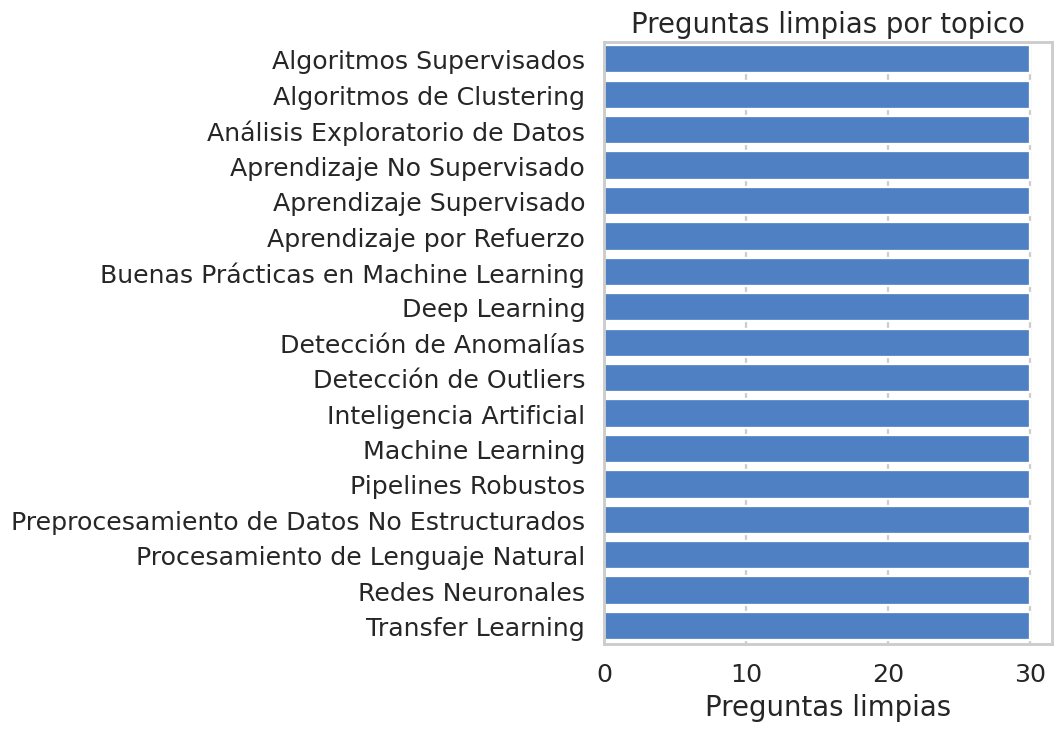

In [7]:
# Distribucion de preguntas limpias por topico (base de conocimiento).
plt.figure(figsize=(10, 7))
order = balance_tbl.sort_values("limpias").index
sns.barplot(x=balance_tbl.loc[order, "limpias"], y=order, color="#3b7dd8")
plt.xlabel("Preguntas limpias"); plt.ylabel(""); plt.title("Preguntas limpias por topico")
plt.tight_layout(); savefig("fig_01_balance_topicos.png"); plt.show()

[FIG] /content/figuras/fig_02_ruido_por_topico.png


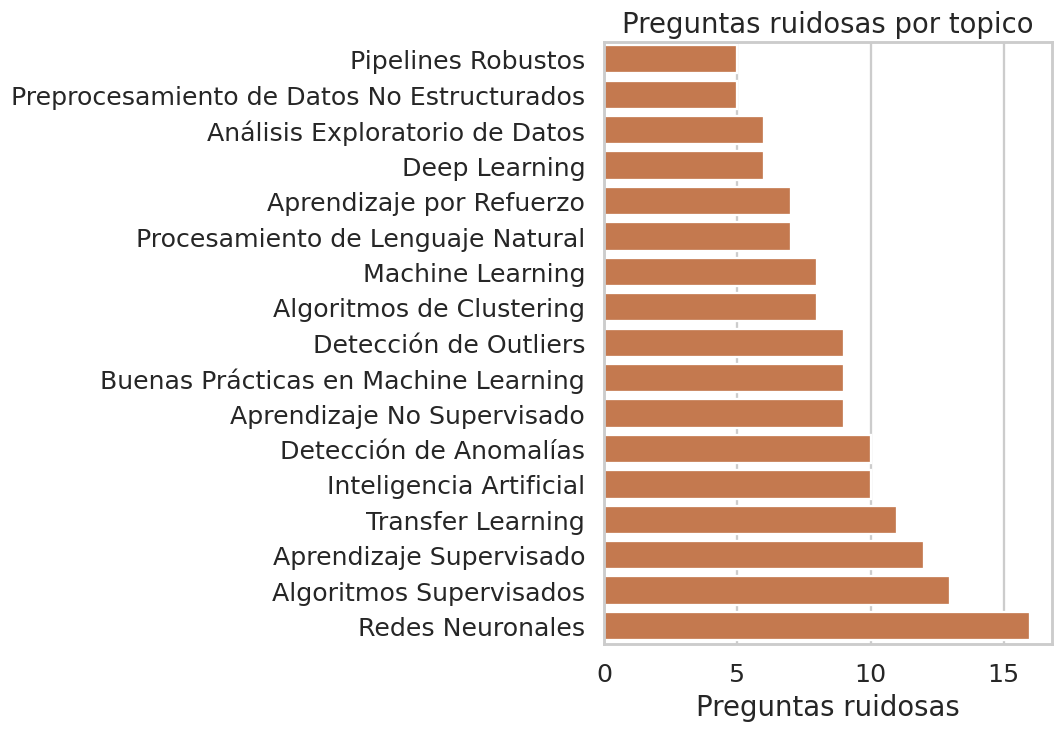

In [8]:
# Distribucion de preguntas ruidosas por topico (conjunto de prueba): no es uniforme.
plt.figure(figsize=(10, 7))
order = balance_tbl.sort_values("ruidosas").index
sns.barplot(x=balance_tbl.loc[order, "ruidosas"], y=order, color="#d8743b")
plt.xlabel("Preguntas ruidosas"); plt.ylabel(""); plt.title("Preguntas ruidosas por topico")
plt.tight_layout(); savefig("fig_02_ruido_por_topico.png"); plt.show()

### Caracterizacion del ruido

Parte del ruido sintetico inyecta un prefijo literal ("Version modificada:") y saltos de linea que no representan ruido real de un usuario; se eliminan de forma documentada y reversible, conservando el resto (tipeo, mayusculas, abreviaturas, reformulacion). Un clasificador heuristico determinista etiqueta el tipo de ruido de cada consulta para analizar despues la robustez por categoria.

In [9]:
# Limpieza minima y documentada de la entrada del usuario.
def clean_user_text(s):
    s = re.sub(r"(?is)^\s*versi[oó]n\s+modificada\s*:\s*", "", str(s))  # artefacto de generacion sintetica
    return re.sub(r"\s+", " ", s).strip()

# Clasificador heuristico determinista del tipo de ruido (sobre las 151 consultas).
def _norm(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    return re.sub(r"[^a-zA-Z0-9 ]", " ", s).lower()

_SMS = {"q", "xq", "pq", "tb", "tmb", "xfa", "dnd", "tqm", "bn", "d", "x"}

def noise_type(orig, noisy):
    o, n = _norm(orig), _norm(noisy)
    if o.split() == n.split() and str(orig) != str(noisy):
        return "mayus_punt"          # solo mayusculas / acentos / puntuacion
    ot, nt = set(o.split()), set(n.split())
    jac = len(ot & nt) / max(1, len(ot | nt))
    if jac < 0.5:
        return "reformulacion"       # palabras distintas, mismo significado
    if (nt - ot) & _SMS or set(n.split()) & _SMS:
        return "abreviatura"         # estilo SMS (q, d, xq...)
    if difflib.SequenceMatcher(None, o, n).ratio() < 0.93:
        return "tipografico"         # errores de tipeo / ortografia
    return "mixto"

_clean_idx = df[df["has_noise"] == False].set_index("id")
_noisy = df[df["has_noise"] == True].copy()
_noisy["question_proc"] = _noisy["question"].map(clean_user_text)
_noisy["noise_type"] = [noise_type(_clean_idx.loc[r["original_question_id"], "question"], r["question_proc"])
                        for _, r in _noisy.iterrows()]

print("Consultas con artefacto 'Version modificada':",
      int(df[df["has_noise"] == True]["question"].str.contains("modificada", case=False).sum()))
print("Distribucion de tipos de ruido:", _noisy["noise_type"].value_counts().to_dict())

# Validacion cualitativa: un par limpia/ruidosa por categoria.
rows = []
for cat in ["mayus_punt", "tipografico", "abreviatura", "reformulacion", "mixto"]:
    sub = _noisy[_noisy["noise_type"] == cat]
    if len(sub):
        r = sub.iloc[0]
        rows.append([cat, _clean_idx.loc[r["original_question_id"], "question"], r["question_proc"]])
pd.DataFrame(rows, columns=["tipo", "pregunta_limpia", "pregunta_ruidosa"])

Consultas con artefacto 'Version modificada': 25
Distribucion de tipos de ruido: {'abreviatura': 73, 'reformulacion': 54, 'mixto': 10, 'tipografico': 10, 'mayus_punt': 4}


,tipo,pregunta_limpia,pregunta_ruidosa
0,mayus_punt,¿Cómo puede la IA ayudar a predecir desastres ...,¿comO pUeDe lA ia ayudAr a predecir desastres ...
1,tipografico,¿Cómo se realiza el análisis de sentimientos e...,¿Como se hace el analisis de sentiminetos en u...
2,abreviatura,"¿Qué es el ""machine learning"" supervisado, no ...",q es el machine learning supervisado no superv...
3,reformulacion,¿Cuál es el papel del procesamiento del lengua...,q papel juega el PLN en la IA? osea q hace exa...
4,mixto,¿Cómo puedo evaluar la precisión de un modelo ...,¿como puedo evaluar la presicion de un modelo ...


[FIG] /content/figuras/fig_03_tipos_de_ruido.png


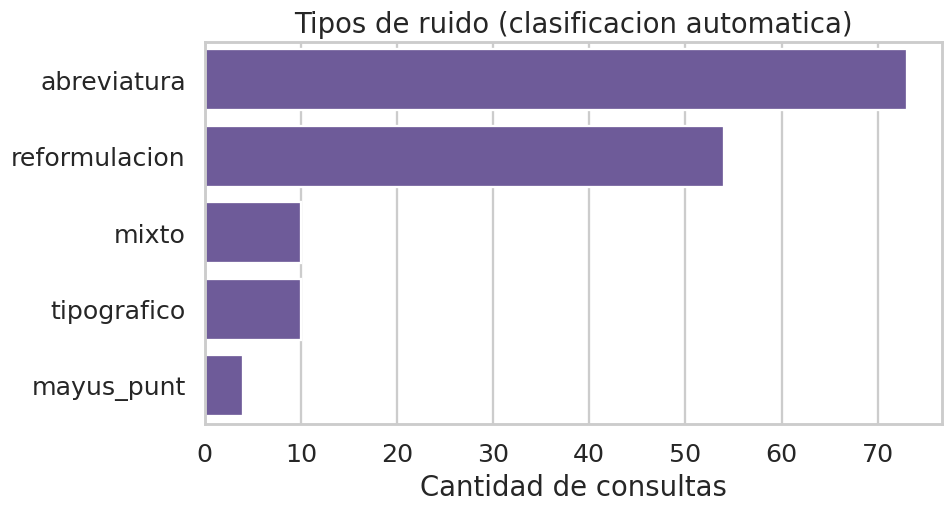

In [10]:
# Distribucion de tipos de ruido.
plt.figure(figsize=(9, 5))
vc = _noisy["noise_type"].value_counts()
sns.barplot(x=vc.values, y=vc.index, color="#6a51a3")
plt.xlabel("Cantidad de consultas"); plt.ylabel(""); plt.title("Tipos de ruido (clasificacion automatica)")
plt.tight_layout(); savefig("fig_03_tipos_de_ruido.png"); plt.show()

Longitud limpias  -> media=12.0 mediana=12
Longitud ruidosas -> media=12.2 mediana=12
[FIG] /content/figuras/fig_04_longitud.png


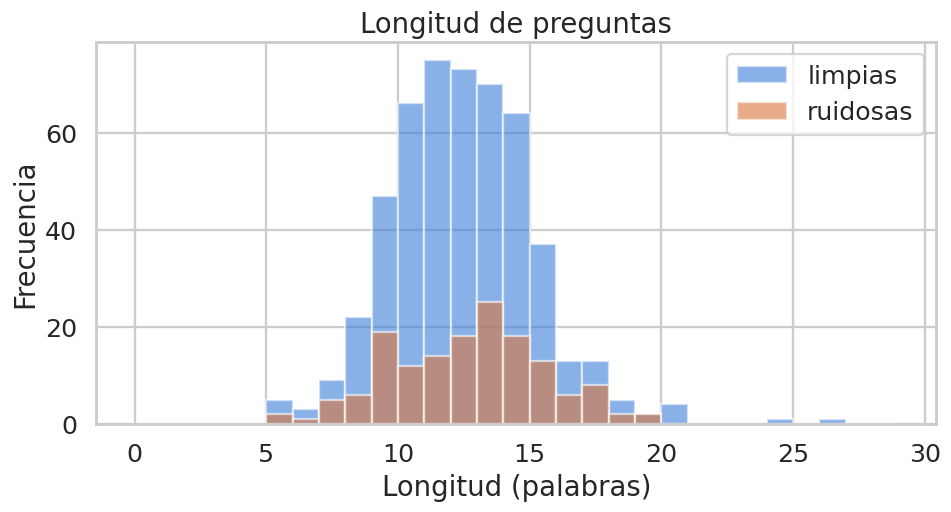

In [11]:
# Longitud de las preguntas: limpias vs ruidosas.
len_clean = df[df["has_noise"] == False]["question"].str.split().map(len)
len_noisy = _noisy["question_proc"].str.split().map(len)
print("Longitud limpias  -> media=%.1f mediana=%.0f" % (len_clean.mean(), len_clean.median()))
print("Longitud ruidosas -> media=%.1f mediana=%.0f" % (len_noisy.mean(), len_noisy.median()))

plt.figure(figsize=(9, 5))
plt.hist(len_clean, bins=range(0, 30), alpha=0.6, label="limpias", color="#3b7dd8")
plt.hist(len_noisy, bins=range(0, 30), alpha=0.6, label="ruidosas", color="#d8743b")
plt.xlabel("Longitud (palabras)"); plt.ylabel("Frecuencia"); plt.legend()
plt.title("Longitud de preguntas")
plt.tight_layout(); savefig("fig_04_longitud.png"); plt.show()

In [12]:
# Separacion definitiva de subconjuntos: no se rompe en el resto del notebook.
df_clean = df[df["has_noise"] == False].reset_index(drop=True)   # 510 -> base de conocimiento
df_noisy = _noisy.reset_index(drop=True)                          # 151 -> conjunto de prueba
clean_questions = df_clean["question"].tolist()
noisy_questions = df_noisy["question_proc"].tolist()              # entrada de usuario ya saneada

# Estructuras para evaluacion.
id2row = {cid: i for i, cid in enumerate(df_clean["id"])}
gt_row = df_noisy["original_question_id"].map(id2row).to_numpy()  # fila del original correcto por consulta
topic_cat = pd.Categorical(df_clean["topic"])
y_topic_clean = topic_cat.codes
y_topic_noisy = pd.Categorical(df_noisy["topic"], categories=topic_cat.categories).codes
print("Base de conocimiento:", len(df_clean), "| Consultas de prueba:", len(df_noisy))

Base de conocimiento: 510 | Consultas de prueba: 151


## Fase 2 - Generacion de embeddings

Tres modelos de sentence-embeddings que varian en tamano (384 vs 768 dimensiones) y en especializacion (multilingue general vs especializado en espanol). Se cargan de a uno y se libera la memoria entre cada uno; los embeddings se cachean en disco.

In [13]:
# Metadata explicita de los modelos candidatos.
MODELS_META = {
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "dim": 384, "params_M": 118, "tipo": "multilingue_general",
        "justificacion": "Linea base eficiente y multilingue, ampliamente validada."},
    "paraphrase-xlm-r-multilingual-v1": {
        "dim": 768, "params_M": 278, "tipo": "multilingue_grande",
        "justificacion": "Mayor capacidad; permite evaluar si la dimension importa."},
    "hiiamsid/sentence_similarity_spanish_es": {
        "dim": 768, "params_M": 135, "tipo": "espanol_especializado",
        "justificacion": "Ajustado para similitud semantica en espanol; mide el efecto del idioma/dominio."},
}
MODELS_TO_EVALUATE = list(MODELS_META.keys())
MODELS_TO_EVALUATE

['paraphrase-multilingual-MiniLM-L12-v2',
 'paraphrase-xlm-r-multilingual-v1',
 'hiiamsid/sentence_similarity_spanish_es']

In [14]:
# Carga secuencial con liberacion de memoria; reanudable via checkpoints.
EMB = {}
benchmark = load_benchmark()
done = {r["model"] for r in benchmark}
set_seeds()

for name in MODELS_TO_EVALUATE:
    cp_c = os.path.join(CHECKPOINT_DIR, "emb_%s_clean.npy" % _safe(name))
    cp_n = os.path.join(CHECKPOINT_DIR, "emb_%s_noisy.npy" % _safe(name))
    cached = os.path.exists(cp_c) and os.path.exists(cp_n)

    model = None
    if not cached:
        print("Cargando modelo:", name)
        model = SentenceTransformer(name, device=DEVICE)

    emb_clean = get_or_compute_embeddings(model, clean_questions, name, "clean")
    emb_noisy = get_or_compute_embeddings(model, noisy_questions, name, "noisy")

    if model is not None:  # tiempo de inferencia por consulta sobre 50 consultas
        probe = noisy_questions[:50]
        t0 = time.perf_counter()
        _ = model.encode(probe, batch_size=BATCH_SIZE, normalize_embeddings=True, show_progress_bar=False)
        infer_ms = (time.perf_counter() - t0) / len(probe) * 1000.0
    else:
        infer_ms = next((r["infer_ms"] for r in benchmark if r["model"] == name), float("nan"))

    EMB[name] = {"clean": emb_clean, "noisy": emb_noisy, "dim": int(emb_clean.shape[1]), "infer_ms": infer_ms}

    if name not in done:
        benchmark.append({"model": name, "dim": int(emb_clean.shape[1]),
                          "infer_ms": float(infer_ms), "device": DEVICE})
        save_benchmark(benchmark); mark_done("benchmark_" + name)

    if model is not None:
        del model; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

print("\nEmbeddings listos para:", list(EMB.keys()))

Cargando modelo: paraphrase-multilingual-MiniLM-L12-v2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[COMPUTE] hiiamsid/sentence_similarity_spanish_es (clean) -> (510, 768)  guardado
[COMPUTE] hiiamsid/sentence_similarity_spanish_es (noisy) -> (151, 768)  guardado

Embeddings listos para: ['paraphrase-multilingual-MiniLM-L12-v2', 'paraphrase-xlm-r-multilingual-v1', 'hiiamsid/sentence_similarity_spanish_es']


In [15]:
# Verificacion de shapes contra la dimension documentada.
for name, d in EMB.items():
    exp = MODELS_META[name]["dim"]
    ok = "OK" if d["clean"].shape == (len(df_clean), exp) else "REVISAR"
    print("%-45s clean=%s noisy=%s dim_doc=%d [%s]" % (name, d["clean"].shape, d["noisy"].shape, exp, ok))

paraphrase-multilingual-MiniLM-L12-v2         clean=(510, 384) noisy=(151, 384) dim_doc=384 [OK]
paraphrase-xlm-r-multilingual-v1              clean=(510, 768) noisy=(151, 768) dim_doc=768 [OK]
hiiamsid/sentence_similarity_spanish_es       clean=(510, 768) noisy=(151, 768) dim_doc=768 [OK]


## Fase 3 - Separabilidad de los embeddings

Reduccion a 2D (PCA, t-SNE, UMAP) sobre los embeddings limpios, coloreada por topico, y cuantificacion objetiva de la coherencia de los clusters mediante metricas internas (silhouette, Calinski-Harabasz, Davies-Bouldin) y supervisadas contra el ground-truth de topicos (NMI, ARI, V-measure). t-SNE preserva estructura local y no distancias globales; ambas tecnicas usan semilla fija.

In [16]:
# Separacion compute/plot: reduce_2d calcula coordenadas; plot_2d solo dibuja y guarda.
def reduce_2d(emb, method):
    if method == "pca":
        red = PCA(n_components=2, random_state=RANDOM_STATE)
        return red.fit_transform(emb), red.explained_variance_ratio_.sum()
    if method == "tsne":
        return TSNE(n_components=2, perplexity=30, max_iter=1000, init="pca",
                    random_state=RANDOM_STATE).fit_transform(emb), None
    if method == "umap":
        return umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                         random_state=RANDOM_STATE).fit_transform(emb), None
    raise ValueError(method)

def plot_2d(coords, labels, label_names, title, fname):
    plt.figure(figsize=(11, 7))
    palette = sns.color_palette("tab20", len(label_names))
    for k, nm in enumerate(label_names):
        m = labels == k
        plt.scatter(coords[m, 0], coords[m, 1], s=18, color=palette[k], label=nm)
    plt.title(title); plt.xlabel("dim 1"); plt.ylabel("dim 2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
    plt.tight_layout(); savefig(fname); plt.show()

In [17]:
# Coordenadas 2D por modelo y metodo (compute).
set_seeds()
REDU = {}
for name in MODELS_TO_EVALUATE:
    REDU[name] = {}
    for method in ("pca", "tsne", "umap"):
        coords, var = reduce_2d(EMB[name]["clean"], method)
        REDU[name][method] = coords
        if method == "pca":
            print("%-45s PCA var. explicada (2D) = %.1f%%" % (name, 100 * var))

paraphrase-multilingual-MiniLM-L12-v2         PCA var. explicada (2D) = 14.3%
paraphrase-xlm-r-multilingual-v1              PCA var. explicada (2D) = 15.0%
hiiamsid/sentence_similarity_spanish_es       PCA var. explicada (2D) = 12.7%


[FIG] /content/figuras/fig_05_pca_paraphrase-multilingual-MiniLM-L12-v2.png


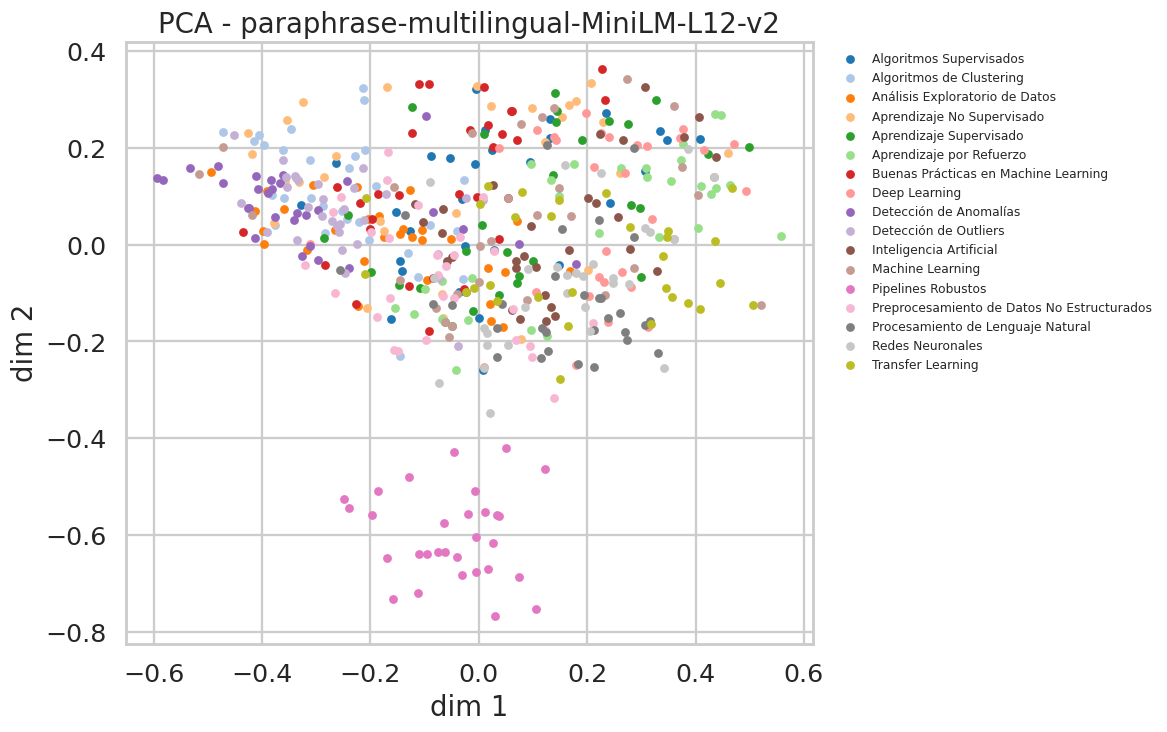

[FIG] /content/figuras/fig_05_tsne_paraphrase-multilingual-MiniLM-L12-v2.png


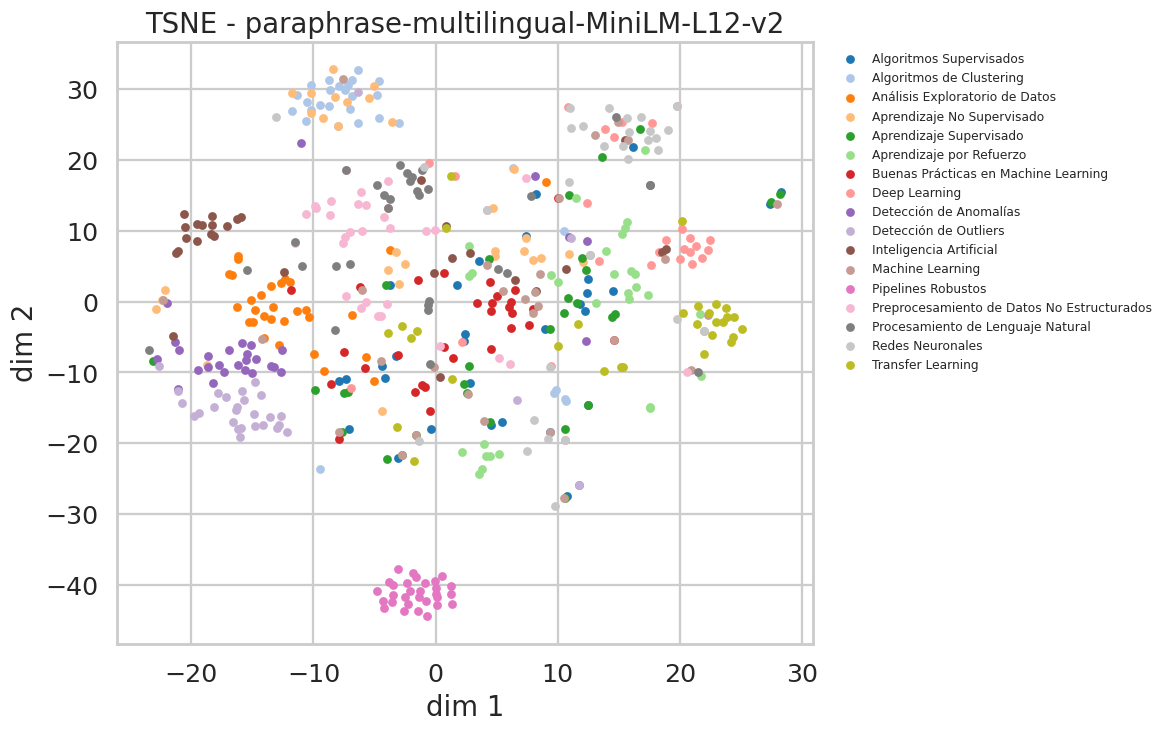

[FIG] /content/figuras/fig_05_umap_paraphrase-multilingual-MiniLM-L12-v2.png


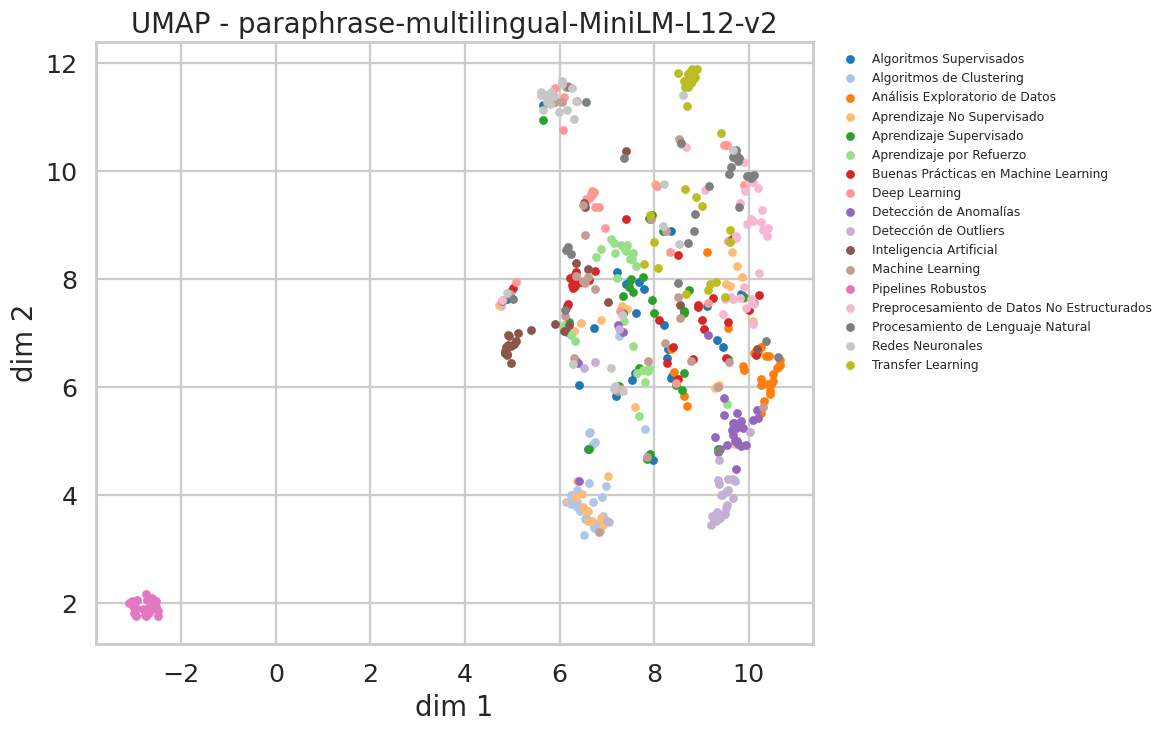

[FIG] /content/figuras/fig_05_pca_paraphrase-xlm-r-multilingual-v1.png


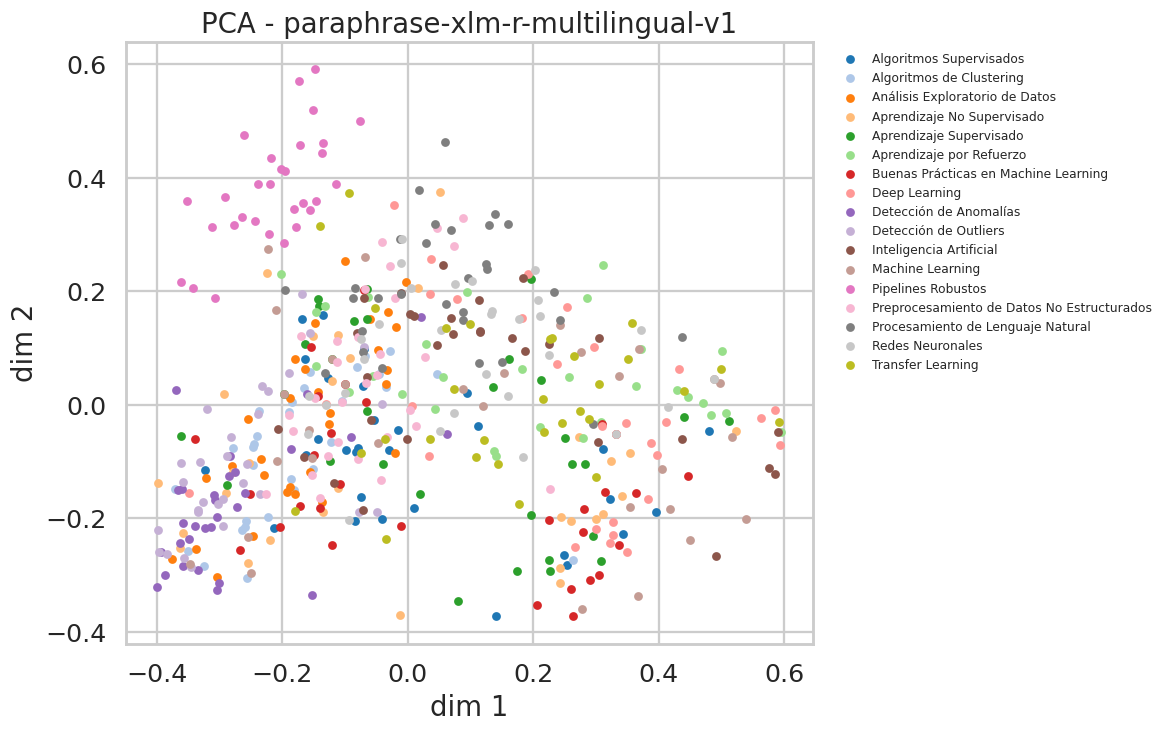

[FIG] /content/figuras/fig_05_tsne_paraphrase-xlm-r-multilingual-v1.png


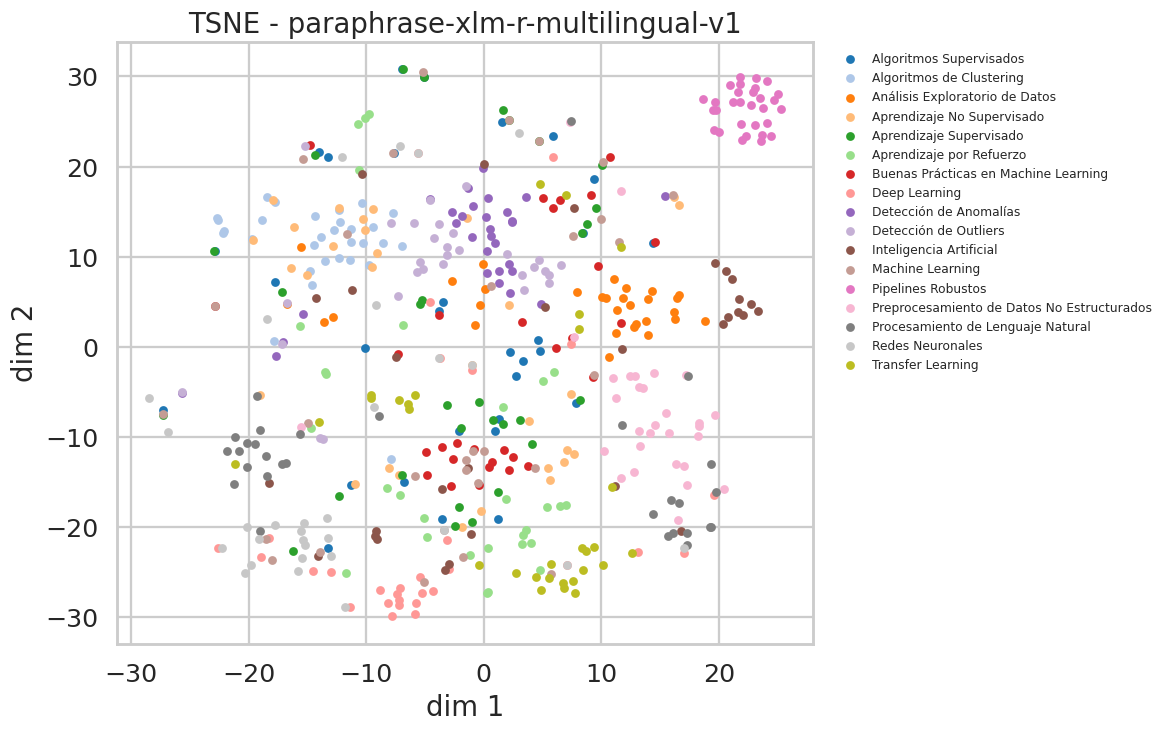

[FIG] /content/figuras/fig_05_umap_paraphrase-xlm-r-multilingual-v1.png


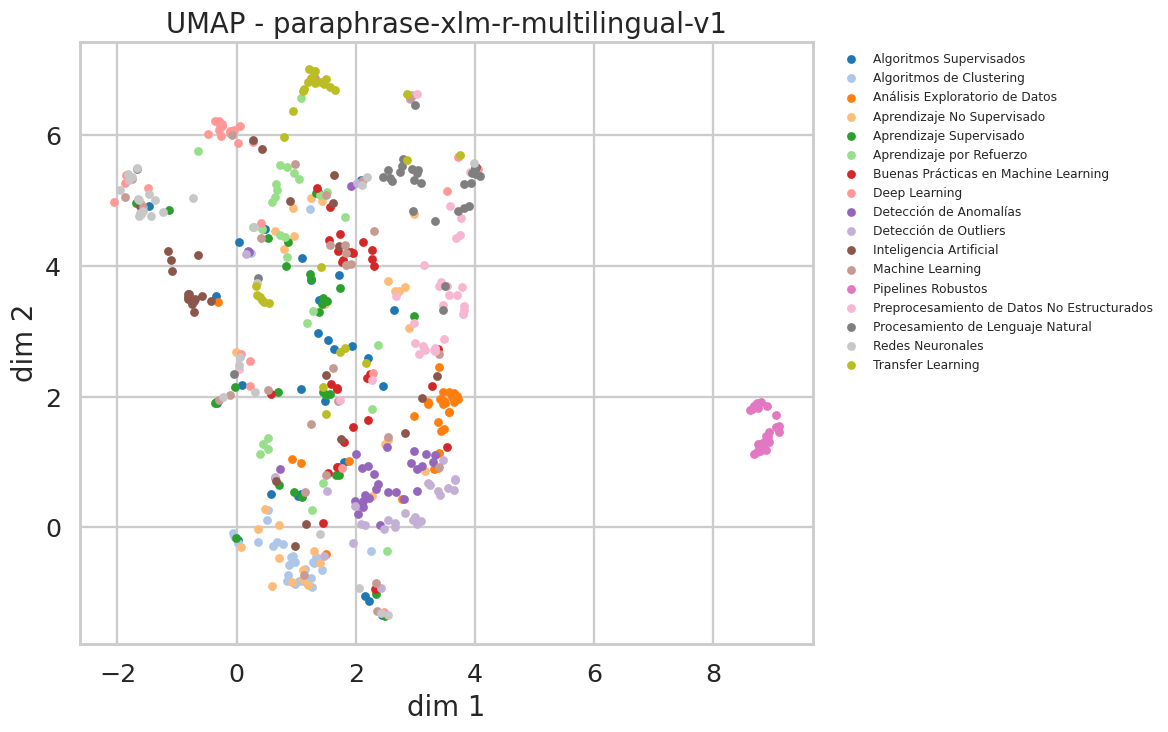

[FIG] /content/figuras/fig_05_pca_hiiamsid_sentence_similarity_spanish_es.png


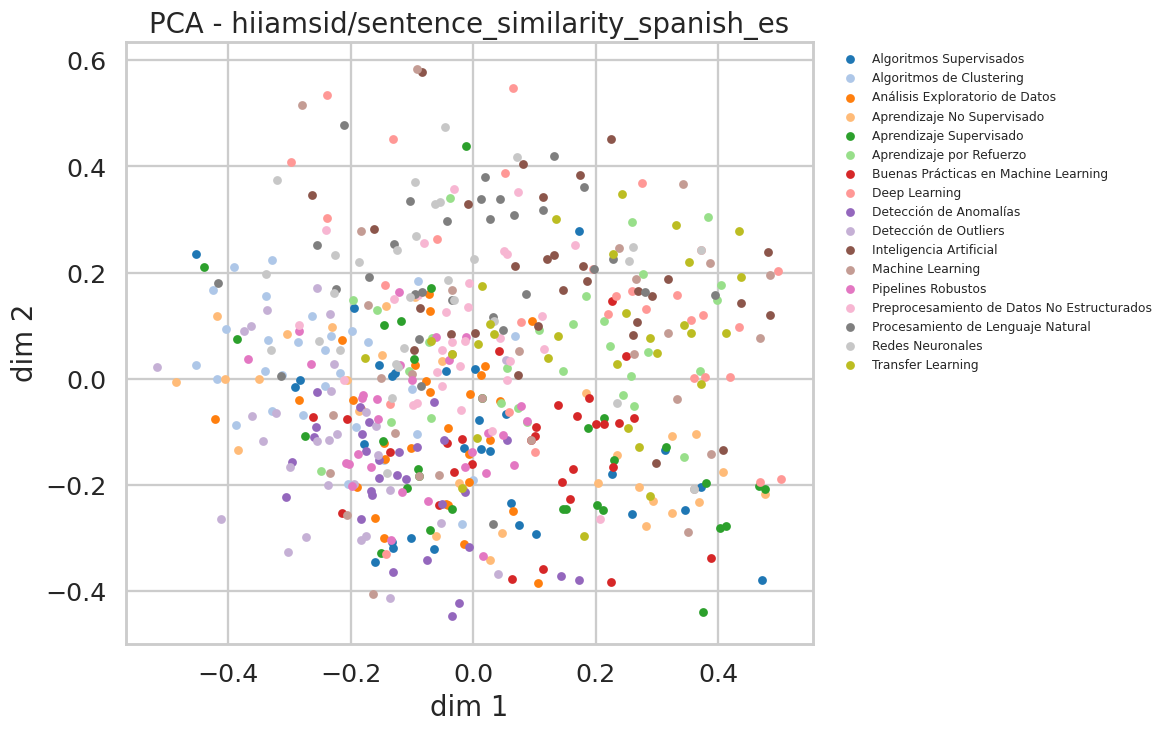

[FIG] /content/figuras/fig_05_tsne_hiiamsid_sentence_similarity_spanish_es.png


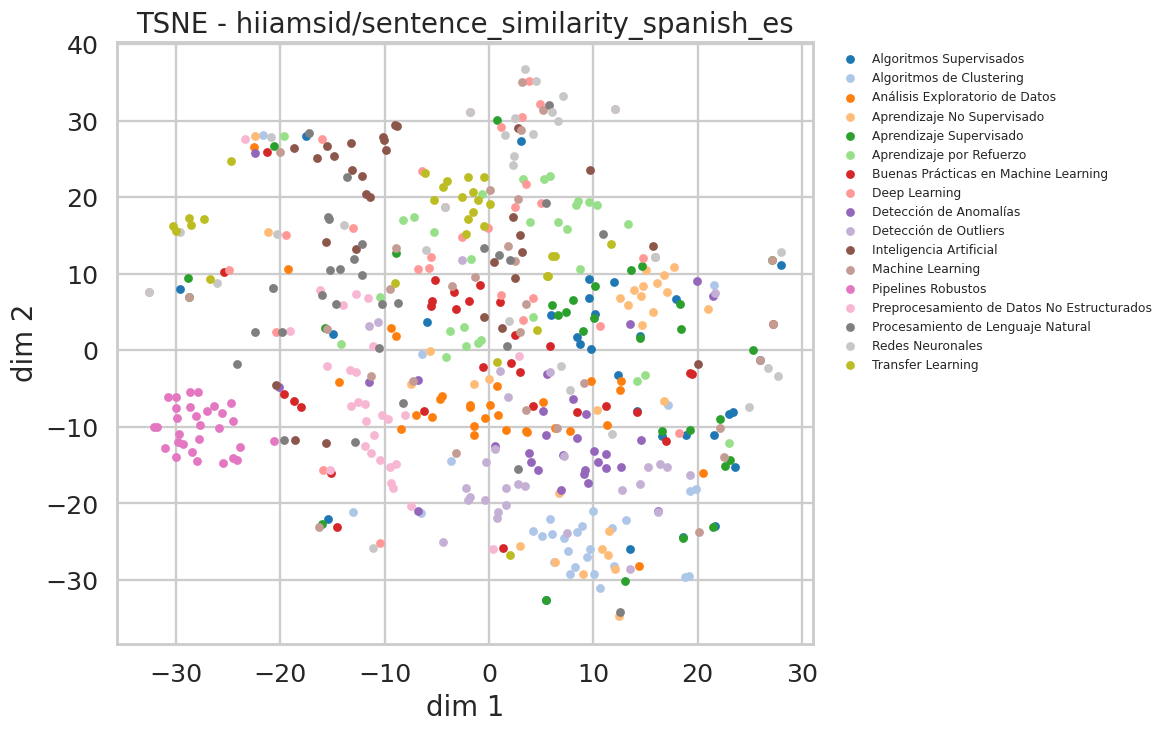

[FIG] /content/figuras/fig_05_umap_hiiamsid_sentence_similarity_spanish_es.png


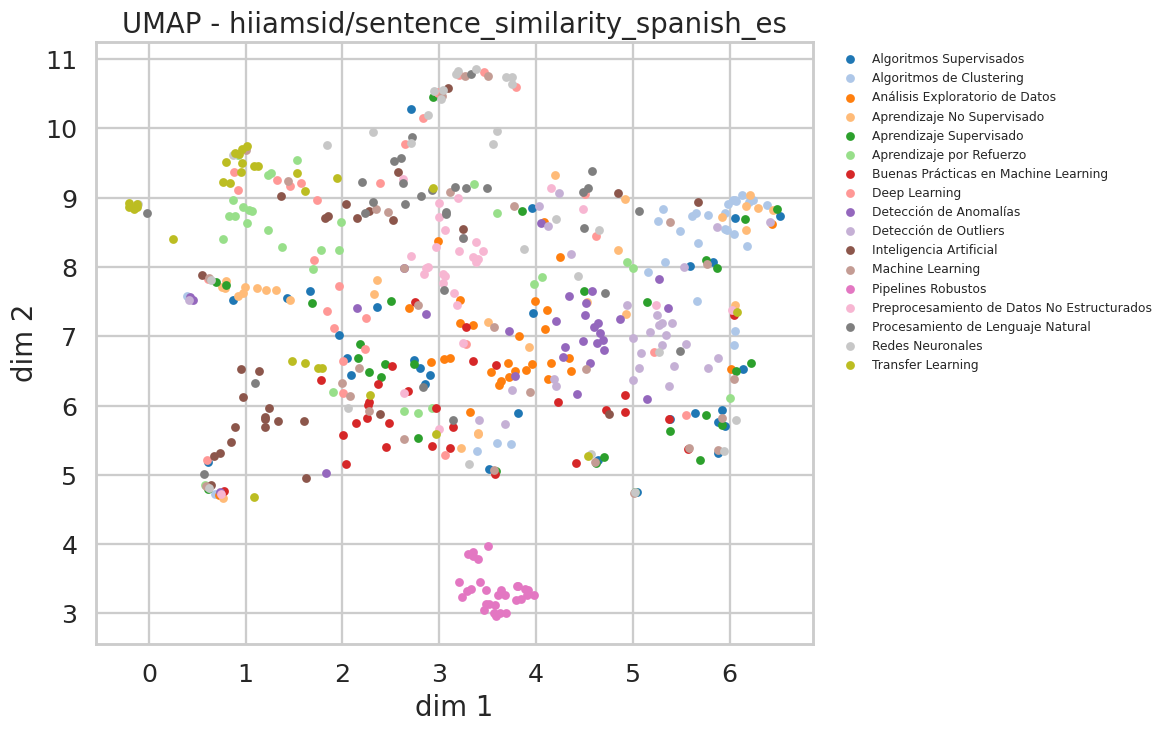

In [18]:
# Visualizaciones (plot). Una figura por modelo y metodo.
labels_names = list(topic_cat.categories)
for name in MODELS_TO_EVALUATE:
    tag = _safe(name)
    for method in ("pca", "tsne", "umap"):
        plot_2d(REDU[name][method], y_topic_clean, labels_names,
                "%s - %s" % (method.upper(), name), "fig_05_%s_%s.png" % (method, tag))

In [19]:
# KMeans con K=17 (17 topicos balanceados) + metricas internas y supervisadas.
set_seeds()
sep_rows, KM_LABELS = [], {}
for name in MODELS_TO_EVALUATE:
    X = EMB[name]["clean"]
    km = KMeans(n_clusters=N_TOPICS, n_init=10, random_state=RANDOM_STATE).fit(X)
    lab = km.labels_; KM_LABELS[name] = lab
    sep_rows.append({
        "modelo": name, "dim": EMB[name]["dim"],
        "silhouette": silhouette_score(X, lab),
        "calinski_harabasz": calinski_harabasz_score(X, lab),
        "davies_bouldin": davies_bouldin_score(X, lab),
        "NMI": normalized_mutual_info_score(y_topic_clean, lab),
        "ARI": adjusted_rand_score(y_topic_clean, lab),
        "V_measure": v_measure_score(y_topic_clean, lab),
    })
sep_df = pd.DataFrame(sep_rows).sort_values("NMI", ascending=False).reset_index(drop=True)
sep_df.to_csv(os.path.join(TAB_DIR, "tabla_separabilidad.csv"), index=False)
sep_df.round(3)

,modelo,dim,silhouette,calinski_harabasz,davies_bouldin,NMI,ARI,V_measure
0,paraphrase-multilingual-MiniLM-L12-v2,384,0.110,16.243,2.528,0.503,0.313,0.503
1,paraphrase-xlm-r-multilingual-v1,768,0.088,15.255,2.676,0.453,0.247,0.453
2,hiiamsid/sentence_similarity_spanish_es,768,0.067,11.158,2.870,0.386,0.205,0.386


[FIG] /content/figuras/fig_06_separabilidad.png


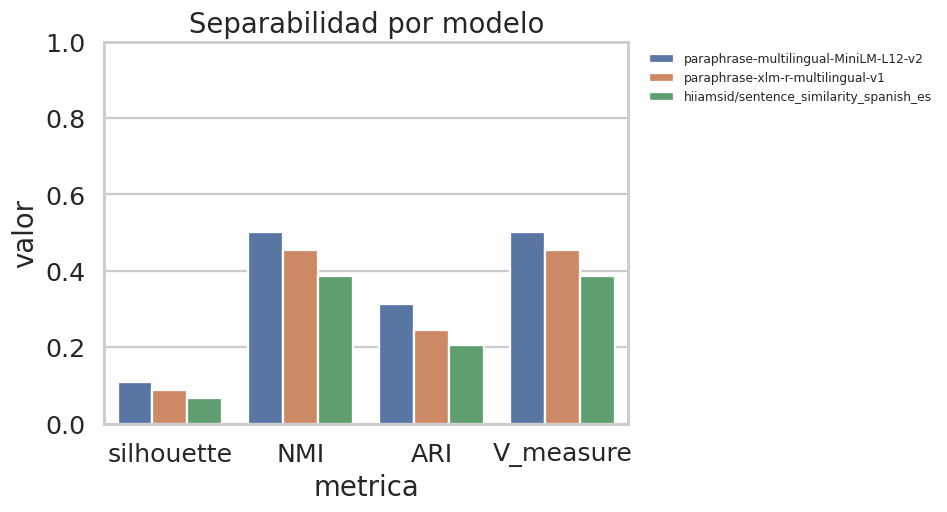

In [20]:
# Comparacion visual de separabilidad (metricas en [0,1], mayor es mejor).
plt.figure(figsize=(9, 5))
m = sep_df.melt(id_vars="modelo", value_vars=["silhouette", "NMI", "ARI", "V_measure"],
                var_name="metrica", value_name="valor")
sns.barplot(data=m, x="metrica", y="valor", hue="modelo"); plt.ylim(0, 1)
plt.title("Separabilidad por modelo")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout(); savefig("fig_06_separabilidad.png"); plt.show()

## Fase 4 - Robustez ante el ruido

Proporcion de consultas ruidosas que recuperan su pregunta original entre las mas similares (Acc@1/3/5) y desglose por tipo de ruido, para contrastar el efecto de la senal lexica distorsionada (tipografico) frente a las reformulaciones semanticas.

In [21]:
# Top-K accuracy: cada consulta ruidosa contra las 510 limpias por similitud coseno.
def topk_for_model(name, Ks=TOP_K):
    En, Ec = EMB[name]["noisy"], EMB[name]["clean"]
    sims = En @ Ec.T                       # coseno (embeddings L2-normalizados)
    order = np.argsort(-sims, axis=1)
    rank_correct = np.array([int(np.where(order[i] == gt_row[i])[0][0]) for i in range(len(df_noisy))])
    return {k: float(np.mean(rank_correct < k)) for k in Ks}, rank_correct, sims, order

topk_rows, RANKS, SIMS, ORDER = [], {}, {}, {}
for name in MODELS_TO_EVALUATE:
    acc, rk, sims, order = topk_for_model(name)
    RANKS[name], SIMS[name], ORDER[name] = rk, sims, order
    topk_rows.append({"modelo": name, **{("acc@%d" % k): acc[k] for k in TOP_K}})
topk_df = pd.DataFrame(topk_rows).sort_values("acc@1", ascending=False).reset_index(drop=True)
topk_df.to_csv(os.path.join(TAB_DIR, "tabla_topk.csv"), index=False)
topk_df.round(3)

,modelo,acc@1,acc@3,acc@5
0,paraphrase-xlm-r-multilingual-v1,0.914,0.987,0.987
1,paraphrase-multilingual-MiniLM-L12-v2,0.907,0.980,0.987
2,hiiamsid/sentence_similarity_spanish_es,0.887,0.967,0.980


[FIG] /content/figuras/fig_07_topk.png


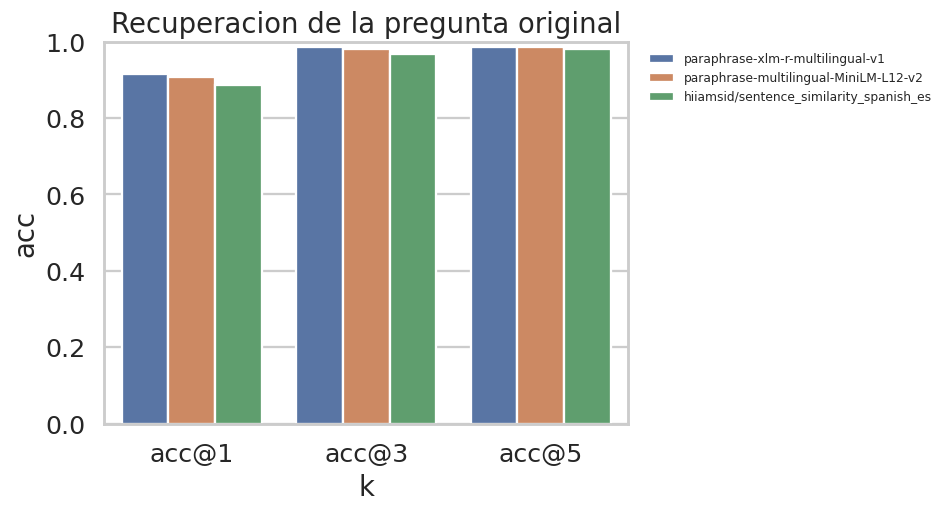

Mejor modelo por Acc@1: paraphrase-xlm-r-multilingual-v1


In [22]:
# Acc@K por modelo.
best_model = topk_df.iloc[0]["modelo"]
plt.figure(figsize=(9, 5))
m = topk_df.melt(id_vars="modelo", value_vars=["acc@1", "acc@3", "acc@5"], var_name="k", value_name="acc")
sns.barplot(data=m, x="k", y="acc", hue="modelo"); plt.ylim(0, 1)
plt.title("Recuperacion de la pregunta original")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout(); savefig("fig_07_topk.png"); plt.show()
print("Mejor modelo por Acc@1:", best_model)

In [23]:
# Accuracy@1 por tipo de ruido para cada modelo.
acc_noise = []
for name in MODELS_TO_EVALUATE:
    tmp = df_noisy.copy(); tmp["hit1"] = (RANKS[name] == 0).astype(int)
    acc_noise.append(pd.Series(tmp.groupby("noise_type")["hit1"].mean(), name=name))
acc_noise_df = pd.concat(acc_noise, axis=1).round(3)
acc_noise_df.to_csv(os.path.join(TAB_DIR, "tabla_acc_por_tipo_ruido.csv"))
acc_noise_df

,paraphrase-multilingual-MiniLM-L12-v2,paraphrase-xlm-r-multilingual-v1,hiiamsid/sentence_similarity_spanish_es
noise_type,,,
abreviatura,0.890,0.932,0.918
mayus_punt,1.000,1.000,1.000
mixto,0.800,1.000,1.000
reformulacion,0.944,0.870,0.815
tipografico,0.900,0.900,0.900


[FIG] /content/figuras/fig_08_acc_por_tipo_ruido.png


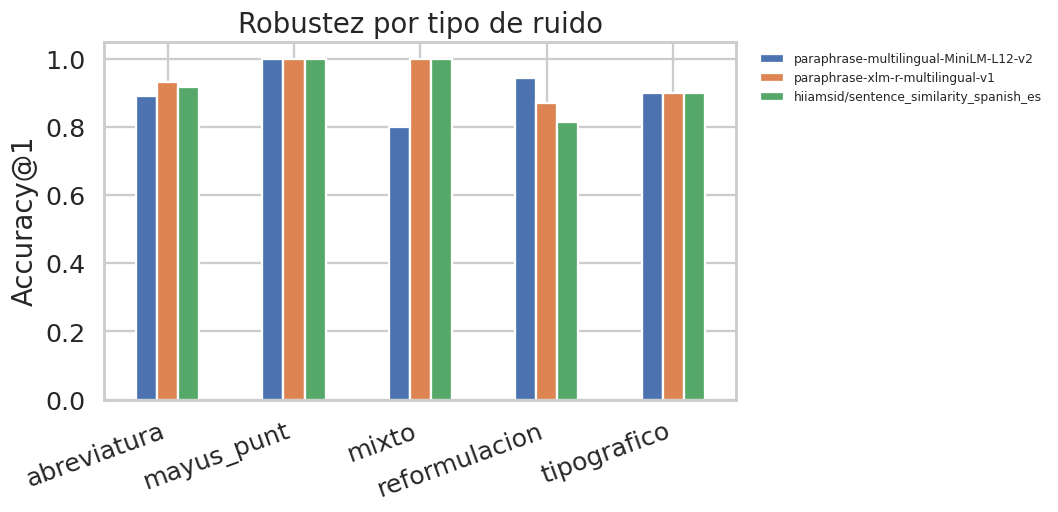

In [24]:
# Robustez por tipo de ruido.
plt.figure(figsize=(10, 5))
acc_noise_df.plot(kind="bar", ax=plt.gca()); plt.ylim(0, 1.05)
plt.ylabel("Accuracy@1"); plt.xlabel(""); plt.title("Robustez por tipo de ruido")
plt.xticks(rotation=20, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout(); savefig("fig_08_acc_por_tipo_ruido.png"); plt.show()

Positivos: media=0.883 | Negativos: media=0.344
[FIG] /content/figuras/fig_09_hist_similitudes.png


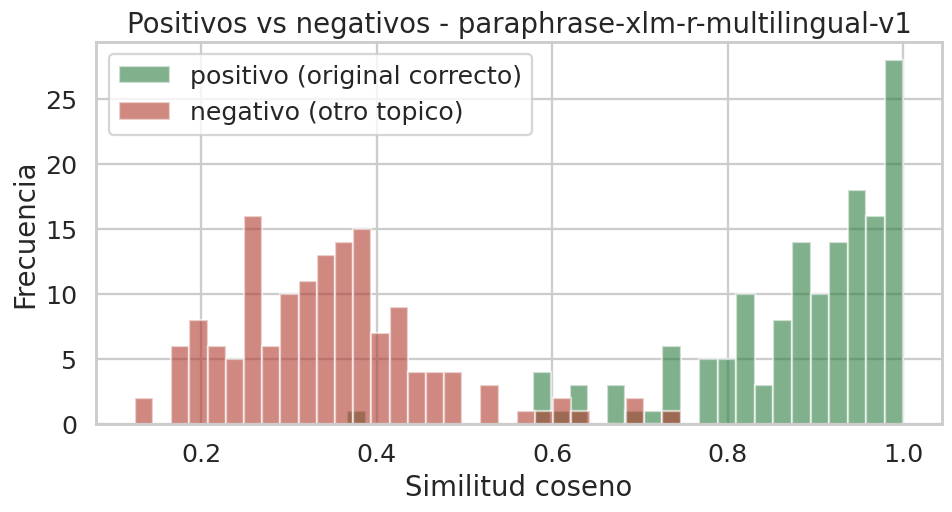

In [25]:
# Mejor modelo: similitud del positivo correcto vs un negativo aleatorio de otro topico.
set_seeds()
sims_b = SIMS[best_model]
pos = np.array([sims_b[i, gt_row[i]] for i in range(len(df_noisy))])
neg = np.array([sims_b[i, np.random.choice(np.where(y_topic_clean != y_topic_noisy[i])[0])]
                for i in range(len(df_noisy))])
print("Positivos: media=%.3f | Negativos: media=%.3f" % (pos.mean(), neg.mean()))

plt.figure(figsize=(9, 5))
plt.hist(pos, bins=30, alpha=0.6, label="positivo (original correcto)", color="#2c7c3f")
plt.hist(neg, bins=30, alpha=0.6, label="negativo (otro topico)", color="#b03a2e")
plt.xlabel("Similitud coseno"); plt.ylabel("Frecuencia"); plt.legend()
plt.title("Positivos vs negativos - %s" % best_model)
plt.tight_layout(); savefig("fig_09_hist_similitudes.png"); plt.show()

## Fase 5 - Umbral de similitud

Calibracion de un umbral de decision a partir de pares positivos (consulta ruidosa vs su original) y negativos (vs otra pregunta), usando como criterio una precision objetivo, mas una zona de incertidumbre para el ruteo. Se verifica ademas que sobre embeddings normalizados el ranking por coseno y por distancia euclidiana coinciden, lo que justifica usar coseno.

In [26]:
# Curva cobertura vs precision sobre el conjunto de prueba (mejor modelo).
set_seeds()
sims_b, order_b = SIMS[best_model], ORDER[best_model]
top1_correct = (order_b[:, 0] == gt_row)
maxsim = sims_b.max(axis=1)

ths = np.round(np.arange(0.40, 1.00, 0.01), 2)
cov, prec = [], []
for t in ths:
    ans = maxsim >= t
    cov.append(float(ans.mean()))
    prec.append(float(top1_correct[ans].mean()) if ans.sum() else np.nan)
cov, prec = np.array(cov), np.array(prec)

TARGET_PREC = 0.90                          # criterio de negocio: precision minima exigida
ok = np.where(prec >= TARGET_PREC)[0]
thr_high = float(ths[ok[0]]) if len(ok) else float(ths[-1])
thr_low = round(thr_high - 0.05, 2)
print("Umbral alto (prec>=%.2f) = %.2f | cobertura = %.2f | banda de incertidumbre = [%.2f, %.2f]"
      % (TARGET_PREC, thr_high, cov[list(ths).index(thr_high)], thr_low, thr_high))

pd.DataFrame({"umbral": ths, "cobertura": cov, "precision": prec}).to_csv(
    os.path.join(TAB_DIR, "tabla_umbral.csv"), index=False)

Umbral alto (prec>=0.90) = 0.40 | cobertura = 1.00 | banda de incertidumbre = [0.35, 0.40]


[FIG] /content/figuras/fig_10_umbral.png


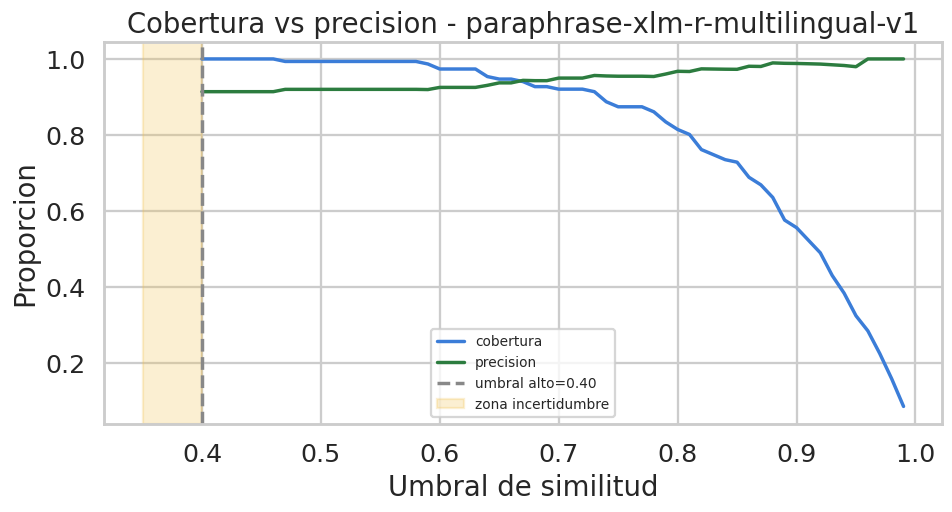

In [27]:
# Cobertura vs precision con la zona de incertidumbre sombreada.
plt.figure(figsize=(9, 5))
plt.plot(ths, cov, label="cobertura", color="#3b7dd8")
plt.plot(ths, prec, label="precision", color="#2c7c3f")
plt.axvline(thr_high, ls="--", color="#888", label="umbral alto=%.2f" % thr_high)
plt.axvspan(thr_low, thr_high, color="#f2c14e", alpha=0.25, label="zona incertidumbre")
plt.xlabel("Umbral de similitud"); plt.ylabel("Proporcion"); plt.legend(fontsize=9)
plt.title("Cobertura vs precision - %s" % best_model)
plt.tight_layout(); savefig("fig_10_umbral.png"); plt.show()

In [28]:
# Politica de tres niveles para produccion y verificacion coseno vs euclidiana.
def route_query(sim_top1):
    if sim_top1 >= thr_high: return "automatica"
    if sim_top1 >= thr_low:  return "tentativa_con_confirmacion"
    return "derivar_a_humano"

ruteo = pd.Series([route_query(s) for s in maxsim]).value_counts(normalize=True).round(3)
print("Ruteo de las consultas de prueba:", ruteo.to_dict())

Ec, En = EMB[best_model]["clean"], EMB[best_model]["noisy"]
equiv = all(list(np.argsort(-(En[i] @ Ec.T))[:5]) == list(np.argsort(np.linalg.norm(Ec - En[i], axis=1))[:5])
            for i in range(5))
print("Ranking coseno == ranking euclidiano (top-5) en 5 consultas:", equiv)

Ruteo de las consultas de prueba: {'automatica': 1.0}
Ranking coseno == ranking euclidiano (top-5) en 5 consultas: True


## Fase 6 - Pipelines de busqueda

Recomendador base que busca solo en la base limpia y aplica el umbral, y un pipeline alternativo de dos etapas (clasificacion de topico por centroide y luego busqueda dentro del topico). Se compara su precision y su costo de busqueda, relevante al escalar la base de conocimiento.

In [29]:
# Recomendador base. En produccion se codifica la consulta nueva con el modelo elegido;
# aqui se evalua con embeddings ya calculados para no recargar el modelo.
def recommend_from_index(i, name=None):
    name = name or best_model
    sims = SIMS[name][i]
    j = int(np.argmax(sims)); s = float(sims[j])
    return {"consulta": df_noisy.iloc[i]["question_proc"],
            "pregunta_recuperada": df_clean.iloc[j]["question"],
            "similitud": round(s, 3), "decision": route_query(s),
            "correcta": bool(j == gt_row[i])}

pd.DataFrame([recommend_from_index(i) for i in [0, 5, 20, 60, 120]])

,consulta,pregunta_recuperada,similitud,decision,correcta
0,q papel juega el PLN en la IA? osea q hace exa...,¿Cuál es el papel del aprendizaje automático e...,0.787,automatica,False
1,q es el machine learning supervisado no superv...,"¿Qué es el ""machine learning"" supervisado, no ...",0.939,automatica,True
2,¿cuál es la diferencia entre aprendizaje super...,¿Cuál es la diferencia entre aprendizaje super...,0.982,automatica,True
3,¿En q consiste la planificacion montecarlo y c...,¿En qué consiste el algoritmo Q-learning y cuá...,0.642,automatica,False
4,¿Como puedo integrar herramientas de analisis ...,¿Cómo puedo integrar herramientas de análisis ...,0.913,automatica,True


In [30]:
# Pipeline de dos etapas: centroide por topico -> busqueda dentro del topico predicho.
def build_centroids(name):
    X = EMB[name]["clean"]
    C = np.vstack([X[y_topic_clean == t].mean(0) for t in range(N_TOPICS)])
    return C / np.clip(np.linalg.norm(C, axis=1, keepdims=True), 1e-9, None)

def two_stage_eval(name):
    En, Ec = EMB[name]["noisy"], EMB[name]["clean"]
    C = build_centroids(name)
    pred_topic = np.argmax(En @ C.T, axis=1)
    final_hit = np.zeros(len(df_noisy), dtype=bool)
    for i in range(len(df_noisy)):
        mask = np.where(y_topic_clean == pred_topic[i])[0]
        best = mask[int(np.argmax(En[i] @ Ec[mask].T))]
        final_hit[i] = (best == gt_row[i])
    return pred_topic, (pred_topic == y_topic_noisy), final_hit

In [31]:
# Evaluacion del pipeline de dos etapas vs busqueda directa sobre las 151 consultas.
ts_rows, TS = [], {}
for name in MODELS_TO_EVALUATE:
    pt, tok, fh = two_stage_eval(name); TS[name] = (pt, tok, fh)
    ts_rows.append({
        "modelo": name,
        "acc_topico_etapa1": float(tok.mean()),
        "acc@1_dos_etapas": float(fh.mean()),
        "acc@1_base": float(np.mean(RANKS[name] == 0)),
        "acc@1_dado_topico_ok": float(fh[tok].mean()) if tok.sum() else np.nan,
        "acc@1_dado_topico_mal": float(fh[~tok].mean()) if (~tok).sum() else np.nan,
    })
ts_df = pd.DataFrame(ts_rows).round(3)
ts_df.to_csv(os.path.join(TAB_DIR, "tabla_dos_etapas.csv"), index=False)
ts_df

,modelo,acc_topico_etapa1,acc@1_dos_etapas,acc@1_base,acc@1_dado_topico_ok,acc@1_dado_topico_mal
0,paraphrase-multilingual-MiniLM-L12-v2,0.609,0.609,0.907,1.000,0.0
1,paraphrase-xlm-r-multilingual-v1,0.589,0.576,0.914,0.978,0.0
2,hiiamsid/sentence_similarity_spanish_es,0.556,0.543,0.887,0.976,0.0


[FIG] /content/figuras/fig_11_dos_etapas.png


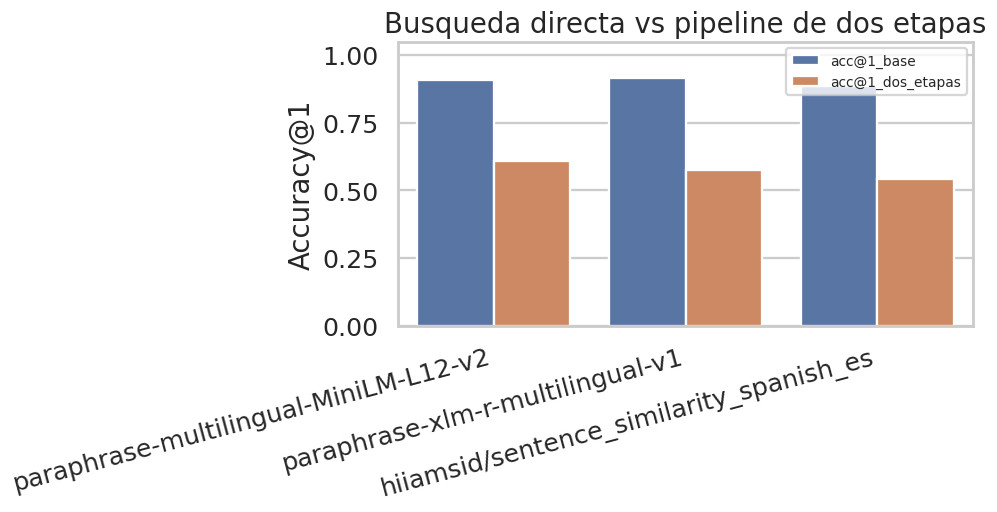

In [32]:
# Busqueda directa vs dos etapas (Acc@1).
plt.figure(figsize=(9, 5))
m = ts_df.melt(id_vars="modelo", value_vars=["acc@1_base", "acc@1_dos_etapas"],
               var_name="pipeline", value_name="acc")
sns.barplot(data=m, x="modelo", y="acc", hue="pipeline"); plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha="right"); plt.ylabel("Accuracy@1"); plt.xlabel("")
plt.title("Busqueda directa vs pipeline de dos etapas"); plt.legend(fontsize=9)
plt.tight_layout(); savefig("fig_11_dos_etapas.png"); plt.show()

In [33]:
# Tiempo de busqueda por consulta: global (510) vs dos etapas (17 centroides + ~30 vectores).
def time_search(name, two_stage, reps=200):
    En, Ec = EMB[name]["noisy"], EMB[name]["clean"]; C = build_centroids(name)
    set_seeds(); idx = np.random.randint(0, len(En), size=reps)
    t0 = time.perf_counter()
    for i in idx:
        if two_stage:
            pt = int(np.argmax(En[i] @ C.T))
            mask = np.where(y_topic_clean == pt)[0]
            _ = np.argmax(En[i] @ Ec[mask].T)
        else:
            _ = np.argmax(En[i] @ Ec.T)
    return (time.perf_counter() - t0) / reps * 1000.0

time_df = pd.DataFrame([{"modelo": n,
                         "ms_global": round(time_search(n, False), 4),
                         "ms_dos_etapas": round(time_search(n, True), 4)}
                        for n in MODELS_TO_EVALUATE])
time_df.to_csv(os.path.join(TAB_DIR, "tabla_tiempo_busqueda.csv"), index=False)
time_df

,modelo,ms_global,ms_dos_etapas
0,paraphrase-multilingual-MiniLM-L12-v2,0.0370,0.0220
1,paraphrase-xlm-r-multilingual-v1,0.0713,0.0275
2,hiiamsid/sentence_similarity_spanish_es,0.0693,0.0251


## Fase 7 - Criterios para produccion

Tabla maestra que consolida calidad de embeddings, robustez, tamano y latencia por modelo, y lectura segun el contexto de despliegue.

In [34]:
# Tabla maestra: una fila por modelo con metricas de todas las fases.
master = (sep_df[["modelo", "dim", "silhouette", "NMI"]]
          .merge(topk_df[["modelo", "acc@1", "acc@3"]], on="modelo")
          .merge(ts_df[["modelo", "acc@1_dos_etapas", "acc_topico_etapa1"]], on="modelo"))
master["params_M"] = master["modelo"].map(lambda n: MODELS_META[n]["params_M"])
master["infer_ms_query"] = master["modelo"].map(lambda n: round(EMB[n]["infer_ms"], 2))
master["tipo"] = master["modelo"].map(lambda n: MODELS_META[n]["tipo"])
master = master.sort_values("acc@1", ascending=False).reset_index(drop=True)
master.to_csv(os.path.join(TAB_DIR, "tabla_maestra.csv"), index=False)
master.round(3)

,modelo,dim,silhouette,NMI,acc@1,acc@3,acc@1_dos_etapas,acc_topico_etapa1,params_M,infer_ms_query,tipo
0,paraphrase-xlm-r-multilingual-v1,768,0.088,0.453,0.914,0.987,0.576,0.589,278,82.02,multilingue_grande
1,paraphrase-multilingual-MiniLM-L12-v2,384,0.110,0.503,0.907,0.980,0.609,0.609,118,34.16,multilingue_general
2,hiiamsid/sentence_similarity_spanish_es,768,0.067,0.386,0.887,0.967,0.543,0.556,135,85.53,espanol_especializado


La calidad de los embeddings (Acc@1, NMI) y el costo de inferencia se leen directamente de la tabla maestra. En un servidor con GPU la latencia deja de ser limitante y conviene el modelo de mayor calidad aunque sea mas grande. En una instancia cloud de CPU de bajo costo, la latencia por consulta del modelo de 768 dimensiones puede volverlo inviable bajo alta concurrencia, favoreciendo el modelo compacto. En hardware local sin GPU prima la disponibilidad offline (descarga unica de pesos, sin dependencia de API) junto con un modelo liviano y rapido; ahi el modelo de 384 dimensiones suele ofrecer el mejor compromiso velocidad/calidad para este caso.

## Limitaciones y consideraciones

- El conjunto de prueba es pequeno (151 consultas): las diferencias finas entre modelos deben leerse con cautela.
- El ruido es sintetico y parte incluia un artefacto de generacion que se removio de forma documentada; el ruido real de clientes financieros puede diferir.
- La similitud se evaluo con coseno sobre embeddings normalizados, sin fine-tuning de los backbones, lo que fija un techo de desempeno alcanzable con mas datos etiquetados o ajuste contrastivo.
- Los centroides de topico se estiman con 30 ejemplos por clase; con bases mayores convendria reestimarlos periodicamente.

## Exportacion para el informe

Inventario de figuras y tablas generadas y empaquetado en un unico zip descargable, para construir el informe con resultados identicos a los del notebook.

In [35]:
# Empaqueta figuras + tablas y descarga el zip (la descarga automatica solo aplica en Colab).
figs = sorted(os.listdir(FIG_DIR)); tabs = sorted(os.listdir(TAB_DIR))
print("Figuras generadas (%d):" % len(figs))
for f in figs: print("   ", f)
print("Tablas generadas (%d):" % len(tabs))
for t in tabs: print("   ", t)

tmp = "/content/_export"
if os.path.exists(tmp): shutil.rmtree(tmp)
os.makedirs(tmp)
for f in figs: shutil.copy(os.path.join(FIG_DIR, f), tmp)
for t in tabs: shutil.copy(os.path.join(TAB_DIR, t), tmp)
shutil.make_archive("/content/figuras_informe", "zip", tmp)
print("\nArchivo listo: /content/figuras_informe.zip")

try:
    from google.colab import files
    files.download("/content/figuras_informe.zip")
except Exception:
    print("(Descarga automatica disponible solo en Colab)")

Figuras generadas (19):
    fig_01_balance_topicos.png
    fig_02_ruido_por_topico.png
    fig_03_tipos_de_ruido.png
    fig_04_longitud.png
    fig_05_pca_hiiamsid_sentence_similarity_spanish_es.png
    fig_05_pca_paraphrase-multilingual-MiniLM-L12-v2.png
    fig_05_pca_paraphrase-xlm-r-multilingual-v1.png
    fig_05_tsne_hiiamsid_sentence_similarity_spanish_es.png
    fig_05_tsne_paraphrase-multilingual-MiniLM-L12-v2.png
    fig_05_tsne_paraphrase-xlm-r-multilingual-v1.png
    fig_05_umap_hiiamsid_sentence_similarity_spanish_es.png
    fig_05_umap_paraphrase-multilingual-MiniLM-L12-v2.png
    fig_05_umap_paraphrase-xlm-r-multilingual-v1.png
    fig_06_separabilidad.png
    fig_07_topk.png
    fig_08_acc_por_tipo_ruido.png
    fig_09_hist_similitudes.png
    fig_10_umbral.png
    fig_11_dos_etapas.png
Tablas generadas (7):
    tabla_acc_por_tipo_ruido.csv
    tabla_dos_etapas.csv
    tabla_maestra.csv
    tabla_separabilidad.csv
    tabla_tiempo_busqueda.csv
    tabla_topk.csv
    tab

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>